# 第4章 RAG — 01 文档切块（Chunking）

RAG（Retrieval-Augmented Generation，检索增强生成）的第一步是把文档切成小块（chunk）供检索。
切块策略直接影响检索质量：块太大会引入噪音，块太小会丢失上下文。

本节涵盖四种常见的切块策略：

| 策略 | 特点 |
|------|------|
| 固定大小切块 | 简单高效，适合均匀文本 |
| 按句子切块   | 保留句子完整性，语义更连贯 |
| 递归字符切块 | LangChain 默认方式，优先按段落、再按句子、最后按字符 |
| 语义切块     | 用 LLM 识别主题边界，质量最高，成本最高 |

In [1]:
import re
import json
import os
import sys

# 将项目根目录加入路径，以便引用 utils
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', '..'))

from dotenv import load_dotenv
load_dotenv()

import litellm
litellm.drop_params = True

def _safe_complete(**kw):
    _m = kw.get('model', '')
    if any(_m.startswith(p) for p in ('openai/gpt-5','openai/o1','openai/o3','openai/o4')):
        kw.pop('temperature', None)
    return litellm.completion(**kw)


MODEL = os.getenv("LLM_MODEL", "openai/gpt-4o-mini")
print(f"使用模型: {MODEL}")

def chat(messages, model=MODEL, temperature=0.0):
    """统一的 LLM 调用入口"""
    response = litellm.completion(
        model=model,
        messages=messages,
        temperature=temperature,
    )
    return response.choices[0].message.content
# gpt-5/o系列不支持自定义temperature值，统一用安全wrapper
def _c(**kw):
    _m = kw.get('model', MODEL)
    if any(_m.startswith(p) for p in ('openai/gpt-5','openai/o1','openai/o3','openai/o4')):
        kw.pop('temperature', None)
    return litellm.completion(**kw)


使用模型: openai/gpt-5-mini


## 示例文本

以下是一段关于人工智能发展的中文示例文本，贯穿本节所有示例。

In [2]:
SAMPLE_TEXT = (
    "人工智能（Artificial Intelligence，简称AI）是计算机科学的一个重要分支，"
    "致力于研究、开发能够模拟、延伸和扩展人类智能的理论、方法和技术。\n"
    "自20世纪50年代图灵提出\u201c机器能思考吗\u201d这一问题以来，人工智能已经历经数十年的发展。\n\n"
    "早期的人工智能研究主要集中在符号逻辑和专家系统上。专家系统通过将领域专家的知识编码为规则，"
    "使计算机能够在特定领域做出与专家相当的决策。\n"
    "然而，这类系统的知识获取瓶颈和脆弱性限制了其广泛应用。进入20世纪80年代，机器学习开始兴起，"
    "研究者们转向让机器从数据中自动学习规律。\n\n"
    "深度学习是机器学习的一个子领域，以人工神经网络为核心，通过多层非线性变换来学习数据的层次化表征。\n"
    "2012年，AlexNet在ImageNet竞赛中以大幅优势取得冠军，标志着深度学习时代的到来。\n"
    "此后，卷积神经网络（CNN）在计算机视觉领域取得了突破性进展，循环神经网络（RNN）及其变体LSTM被广泛应用于自然语言处理任务。\n\n"
    "2017年，Google提出了Transformer架构，彻底改变了自然语言处理领域的格局。\n"
    "基于Transformer的预训练语言模型，如BERT、GPT系列，通过在大规模语料上进行自监督学习，获得了强大的语言理解和生成能力。\n"
    "2022年底，OpenAI发布的ChatGPT引发了全球对大语言模型（LLM）的广泛关注，将AI推向了前所未有的高度。\n\n"
    "当前，人工智能已广泛应用于医疗诊断、自动驾驶、智能客服、内容创作等众多领域。\n"
    "大模型的出现使得通用人工智能（AGI）的讨论再度升温，研究者们正在探索如何让AI系统具备更强的推理能力、"
    "更好的可解释性以及更高的安全性。\n"
    "未来，随着算力的持续提升和数据的不断积累，人工智能将在更多领域发挥不可替代的作用。"
)

print(f"示例文本总字符数: {len(SAMPLE_TEXT)}")
print(f"\n文本预览（前100字符）:")
print(SAMPLE_TEXT[:100])

示例文本总字符数: 753

文本预览（前100字符）:
人工智能（Artificial Intelligence，简称AI）是计算机科学的一个重要分支，致力于研究、开发能够模拟、延伸和扩展人类智能的理论、方法和技术。
自20世纪50年代图灵提出“机器能思考


## 第一节：固定大小切块（Fixed-size Chunking）

最简单的切块方式：按字符数切割，允许相邻块之间有一定重叠（overlap）以保留上下文。

- `chunk_size`：每个块的最大字符数
- `overlap`：相邻块的重叠字符数，避免跨块信息断裂

In [3]:
def fixed_size_split(text, chunk_size=200, overlap=50):
    """
    固定大小切块
    :param text: 输入文本
    :param chunk_size: 每块最大字符数
    :param overlap: 相邻块重叠字符数
    :return: List[str]
    """
    chunks = []
    start = 0
    step = chunk_size - overlap  # 每次前进的步长

    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunks.append(text[start:end])
        if end == len(text):
            break
        start += step

    return chunks


# 演示：chunk_size=200, overlap=50
fixed_chunks = fixed_size_split(SAMPLE_TEXT, chunk_size=200, overlap=50)

print(f"切块参数: chunk_size=200, overlap=50")
print(f"共切出 {len(fixed_chunks)} 个块\n")
print("=" * 50)

for i, chunk in enumerate(fixed_chunks[:2]):
    print(f"\n--- Chunk {i+1} (长度={len(chunk)}) ---")
    print(chunk)

print("\n... (仅展示前2个块) ...")

切块参数: chunk_size=200, overlap=50
共切出 5 个块


--- Chunk 1 (长度=200) ---
人工智能（Artificial Intelligence，简称AI）是计算机科学的一个重要分支，致力于研究、开发能够模拟、延伸和扩展人类智能的理论、方法和技术。
自20世纪50年代图灵提出“机器能思考吗”这一问题以来，人工智能已经历经数十年的发展。

早期的人工智能研究主要集中在符号逻辑和专家系统上。专家系统通过将领域专家的知识编码为规则，使计算机能够在特定领域做出与专家相当的决策。
然而，这类系

--- Chunk 2 (长度=200) ---
。专家系统通过将领域专家的知识编码为规则，使计算机能够在特定领域做出与专家相当的决策。
然而，这类系统的知识获取瓶颈和脆弱性限制了其广泛应用。进入20世纪80年代，机器学习开始兴起，研究者们转向让机器从数据中自动学习规律。

深度学习是机器学习的一个子领域，以人工神经网络为核心，通过多层非线性变换来学习数据的层次化表征。
2012年，AlexNet在ImageNet竞赛中以大幅优势取得冠军，标志着

... (仅展示前2个块) ...


## 第二节：按句子切块（Sentence-based Chunking）

中英文句子以 `。！？.!?` 等标点结束。按句子切块能保留语义完整性，
但单个句子可能过短，因此设置 `max_chunk_size` 将多个句子合并为一个块。

In [4]:
def split_by_sentences(text, max_chunk_size=300):
    """
    按句子切块：先按中英文句末标点拆分句子，再合并到 max_chunk_size 以内。
    :param text: 输入文本
    :param max_chunk_size: 每块最大字符数
    :return: List[str]
    """
    # 用正则在句末标点后拆分，保留标点
    sentences = re.split(r'(?<=[。！？.!?])\s*', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    chunks = []
    current_chunk = ""

    for sentence in sentences:
        # 如果加入当前句子后超过上限，先保存当前块
        if current_chunk and len(current_chunk) + len(sentence) > max_chunk_size:
            chunks.append(current_chunk.strip())
            current_chunk = sentence
        else:
            current_chunk += sentence

    if current_chunk.strip():
        chunks.append(current_chunk.strip())

    return chunks


# 演示
sentence_chunks = split_by_sentences(SAMPLE_TEXT, max_chunk_size=300)

print(f"切块参数: max_chunk_size=300")
print(f"共切出 {len(sentence_chunks)} 个块\n")
print("=" * 50)

for i, chunk in enumerate(sentence_chunks[:3]):
    print(f"\n--- Chunk {i+1} (长度={len(chunk)}) ---")
    print(chunk)

print("\n... (仅展示前3个块) ...")

切块参数: max_chunk_size=300
共切出 3 个块


--- Chunk 1 (长度=257) ---
人工智能（Artificial Intelligence，简称AI）是计算机科学的一个重要分支，致力于研究、开发能够模拟、延伸和扩展人类智能的理论、方法和技术。自20世纪50年代图灵提出“机器能思考吗”这一问题以来，人工智能已经历经数十年的发展。早期的人工智能研究主要集中在符号逻辑和专家系统上。专家系统通过将领域专家的知识编码为规则，使计算机能够在特定领域做出与专家相当的决策。然而，这类系统的知识获取瓶颈和脆弱性限制了其广泛应用。进入20世纪80年代，机器学习开始兴起，研究者们转向让机器从数据中自动学习规律。

--- Chunk 2 (长度=274) ---
深度学习是机器学习的一个子领域，以人工神经网络为核心，通过多层非线性变换来学习数据的层次化表征。2012年，AlexNet在ImageNet竞赛中以大幅优势取得冠军，标志着深度学习时代的到来。此后，卷积神经网络（CNN）在计算机视觉领域取得了突破性进展，循环神经网络（RNN）及其变体LSTM被广泛应用于自然语言处理任务。2017年，Google提出了Transformer架构，彻底改变了自然语言处理领域的格局。基于Transformer的预训练语言模型，如BERT、GPT系列，通过在大规模语料上进行自监督学习，获得了强大的语言理解和生成能力。

--- Chunk 3 (长度=206) ---
2022年底，OpenAI发布的ChatGPT引发了全球对大语言模型（LLM）的广泛关注，将AI推向了前所未有的高度。当前，人工智能已广泛应用于医疗诊断、自动驾驶、智能客服、内容创作等众多领域。大模型的出现使得通用人工智能（AGI）的讨论再度升温，研究者们正在探索如何让AI系统具备更强的推理能力、更好的可解释性以及更高的安全性。未来，随着算力的持续提升和数据的不断积累，人工智能将在更多领域发挥不可替代的作用。

... (仅展示前3个块) ...


## 第三节：递归字符切块（Recursive Character Splitting）

这是 LangChain `RecursiveCharacterTextSplitter` 的核心思想：

1. 优先按段落分隔符 `\n\n` 拆分
2. 如果块仍然过大，再按句末标点拆分
3. 如果仍然过大，按单个换行 `\n` 拆分
4. 最后按字符强制截断

这种层次化策略尽量保留语义结构。

In [5]:
def recursive_split(text, chunk_size=300, overlap=30, separators=None):
    """
    递归字符切块（仿 LangChain RecursiveCharacterTextSplitter）
    :param text: 输入文本
    :param chunk_size: 每块最大字符数
    :param overlap: 相邻块重叠字符数
    :param separators: 按优先级排列的分隔符列表
    :return: List[str]
    """
    if separators is None:
        # 优先级从高到低：段落 > 句子 > 换行 > 空格 > 字符
        separators = ["\\n\\n", r"(?<=[。！？.!?])", "\\n", " ", ""]

    def _split(text, separators):
        """尝试用当前最高优先级分隔符拆分，若块仍过大则递归"""
        if not separators:
            # 无分隔符可用，强制按字符截断
            return [text[i:i+chunk_size] for i in range(0, len(text), chunk_size - overlap)]

        sep = separators[0]
        remaining = separators[1:]

        # 用分隔符拆分
        if sep == "":
            parts = list(text)  # 按单字符拆分
        else:
            parts = re.split(sep, text)

        parts = [p for p in parts if p.strip()]

        # 合并小段，超大段递归处理
        chunks = []
        current = ""

        for part in parts:
            if len(part) > chunk_size:
                # 当前部分本身就超大，递归拆分
                if current.strip():
                    chunks.append(current.strip())
                    current = ""
                chunks.extend(_split(part, remaining))
            elif current and len(current) + len(part) > chunk_size:
                chunks.append(current.strip())
                # overlap：保留当前块末尾部分作为下一块开头
                current = current[-overlap:] + part if overlap else part
            else:
                current += part

        if current.strip():
            chunks.append(current.strip())

        return chunks

    return _split(text, separators)


# 演示
recursive_chunks = recursive_split(SAMPLE_TEXT, chunk_size=300, overlap=30)

print(f"切块参数: chunk_size=300, overlap=30")
print(f"共切出 {len(recursive_chunks)} 个块\n")
print("=" * 50)

for i, chunk in enumerate(recursive_chunks[:3]):
    print(f"\n--- Chunk {i+1} (长度={len(chunk)}) ---")
    print(chunk)

print("\n... (仅展示前3个块) ...")

切块参数: chunk_size=300, overlap=30
共切出 4 个块


--- Chunk 1 (长度=259) ---
人工智能（Artificial Intelligence，简称AI）是计算机科学的一个重要分支，致力于研究、开发能够模拟、延伸和扩展人类智能的理论、方法和技术。
自20世纪50年代图灵提出“机器能思考吗”这一问题以来，人工智能已经历经数十年的发展。早期的人工智能研究主要集中在符号逻辑和专家系统上。专家系统通过将领域专家的知识编码为规则，使计算机能够在特定领域做出与专家相当的决策。
然而，这类系统的知识获取瓶颈和脆弱性限制了其广泛应用。进入20世纪80年代，机器学习开始兴起，研究者们转向让机器从数据中自动学习规律。

--- Chunk 2 (长度=193) ---
，机器学习开始兴起，研究者们转向让机器从数据中自动学习规律。深度学习是机器学习的一个子领域，以人工神经网络为核心，通过多层非线性变换来学习数据的层次化表征。
2012年，AlexNet在ImageNet竞赛中以大幅优势取得冠军，标志着深度学习时代的到来。
此后，卷积神经网络（CNN）在计算机视觉领域取得了突破性进展，循环神经网络（RNN）及其变体LSTM被广泛应用于自然语言处理任务。

--- Chunk 3 (长度=204) ---
网络（RNN）及其变体LSTM被广泛应用于自然语言处理任务。2017年，Google提出了Transformer架构，彻底改变了自然语言处理领域的格局。
基于Transformer的预训练语言模型，如BERT、GPT系列，通过在大规模语料上进行自监督学习，获得了强大的语言理解和生成能力。
2022年底，OpenAI发布的ChatGPT引发了全球对大语言模型（LLM）的广泛关注，将AI推向了前所未有的高度。

... (仅展示前3个块) ...


## 第四节：语义切块（Semantic Chunking with LLM）

让 LLM 理解文本内容，识别自然的主题边界，将文本切分为语义完整的块。

**优点**：块边界更符合人类理解，主题内聚性高  
**缺点**：需要调用 LLM，有延迟和费用成本

Prompt 设计：要求 LLM 输出 JSON 数组，每个元素是一个文本块。

In [6]:
def semantic_split(text, model=MODEL):
    """
    使用 LLM 进行语义切块
    :param text: 输入文本
    :param model: 使用的 LLM 模型
    :return: List[str]
    """
    system_prompt = """你是一个文档处理助手。请将用户提供的文本按自然主题边界切分成若干语义完整的段落。
要求：
1. 每个块聚焦于一个主题，语义完整
2. 不要修改原文内容，保留原始文字
3. 严格以 JSON 数组格式输出，每个元素是一个字符串（即一个文本块）
4. 只输出 JSON，不要有任何额外说明

示例输出格式：
["第一个语义块的内容...", "第二个语义块的内容...", "第三个语义块的内容..."]"""

    user_prompt = f"请切分以下文本：\n\n{text}"

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    raw = chat(messages, model=model, temperature=0.0)

    # 提取 JSON 数组（防止模型输出额外内容）
    match = re.search(r'\[.*\]', raw, re.DOTALL)
    if match:
        chunks = json.loads(match.group())
    else:
        raise ValueError(f"无法解析 LLM 输出为 JSON 数组:\n{raw}")

    return chunks


# 演示（使用较短文本节省 Token）
short_text = SAMPLE_TEXT[:600]
print(f"输入文本（前600字符）长度: {len(short_text)}\n")

print("正在调用 LLM 进行语义切块...")
semantic_chunks = semantic_split(short_text)

print(f"\nLLM 识别出 {len(semantic_chunks)} 个语义块：")
print("=" * 50)

for i, chunk in enumerate(semantic_chunks):
    print(f"\n--- 语义块 {i+1} (长度={len(chunk)}) ---")
    print(chunk)

输入文本（前600字符）长度: 600

正在调用 LLM 进行语义切块...



LLM 识别出 4 个语义块：

--- 语义块 1 (长度=124) ---
人工智能（Artificial Intelligence，简称AI）是计算机科学的一个重要分支，致力于研究、开发能够模拟、延伸和扩展人类智能的理论、方法和技术。
自20世纪50年代图灵提出“机器能思考吗”这一问题以来，人工智能已经历经数十年的发展。

--- 语义块 2 (长度=135) ---
早期的人工智能研究主要集中在符号逻辑和专家系统上。专家系统通过将领域专家的知识编码为规则，使计算机能够在特定领域做出与专家相当的决策。
然而，这类系统的知识获取瓶颈和脆弱性限制了其广泛应用。进入20世纪80年代，机器学习开始兴起，研究者们转向让机器从数据中自动学习规律。

--- 语义块 3 (长度=163) ---
深度学习是机器学习的一个子领域，以人工神经网络为核心，通过多层非线性变换来学习数据的层次化表征。
2012年，AlexNet在ImageNet竞赛中以大幅优势取得冠军，标志着深度学习时代的到来。
此后，卷积神经网络（CNN）在计算机视觉领域取得了突破性进展，循环神经网络（RNN）及其变体LSTM被广泛应用于自然语言处理任务。

--- 语义块 4 (长度=172) ---
2017年，Google提出了Transformer架构，彻底改变了自然语言处理领域的格局。
基于Transformer的预训练语言模型，如BERT、GPT系列，通过在大规模语料上进行自监督学习，获得了强大的语言理解和生成能力。
2022年底，OpenAI发布的ChatGPT引发了全球对大语言模型（LLM）的广泛关注，将AI推向了前所未有的高


## 第五节：对比分析（Comparison Analysis）

对同一份文档运行三种确定性切块方法（固定、句子、递归），
统计并可视化：**块数量、平均大小、最小/最大块大小**。

方法                               块数       平均大小     最小     最大
------------------------------------------------------------
固定大小 (size=200,overlap=50)        5      190.6    153    200
按句子 (max=300)                     3      245.7    206    274
递归字符 (size=300,overlap=30)        4      208.8    179    259


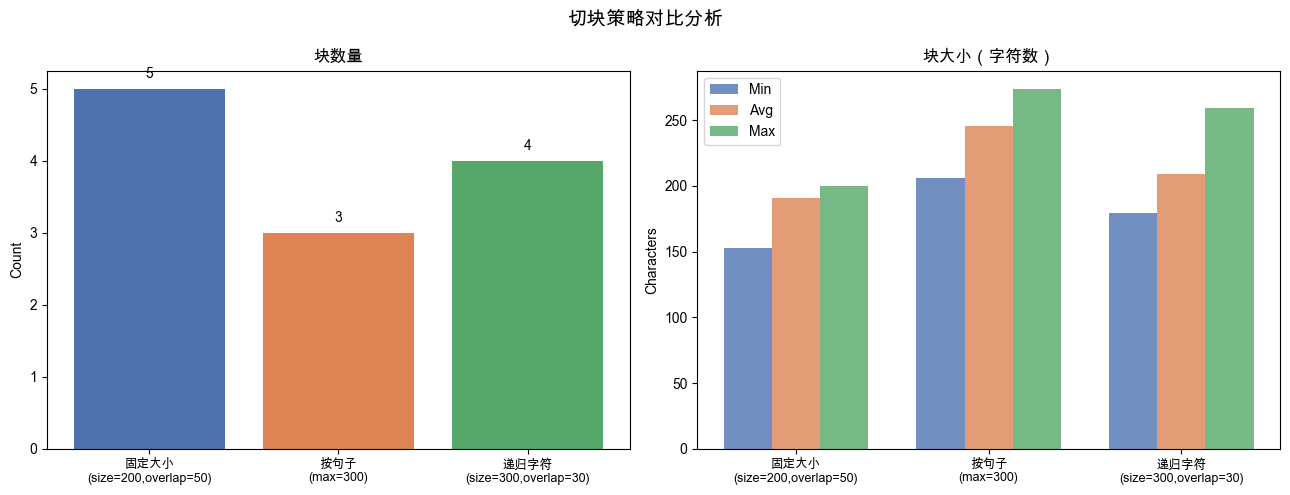

图表已保存为 chunking_comparison.png


In [7]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# 尝试设置中文字体，找不到则退回英文标签
def _setup_chinese_font():
    candidates = ["PingFang SC", "Heiti SC", "SimHei", "WenQuanYi Micro Hei", "Arial Unicode MS"]
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            matplotlib.rcParams["font.family"] = font
            return font
    matplotlib.rcParams["font.family"] = "DejaVu Sans"
    return None

found_font = _setup_chinese_font()
matplotlib.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题


def analyze_chunks(chunks, name):
    """统计一组切块的基本指标"""
    sizes = [len(c) for c in chunks]
    return {
        "name": name,
        "count": len(chunks),
        "avg_size": round(np.mean(sizes), 1),
        "min_size": min(sizes),
        "max_size": max(sizes),
    }


# 运行三种方法
results = [
    analyze_chunks(fixed_size_split(SAMPLE_TEXT, 200, 50),   "固定大小\n(size=200,overlap=50)"),
    analyze_chunks(split_by_sentences(SAMPLE_TEXT, 300),      "按句子\n(max=300)"),
    analyze_chunks(recursive_split(SAMPLE_TEXT, 300, 30),     "递归字符\n(size=300,overlap=30)"),
]

# 打印统计表格
print(f"{'方法':<28} {'块数':>6} {'平均大小':>10} {'最小':>6} {'最大':>6}")
print("-" * 60)
for r in results:
    label = r['name'].replace('\n', ' ')
    print(f"{label:<28} {r['count']:>6} {r['avg_size']:>10} {r['min_size']:>6} {r['max_size']:>6}")


# ---- 可视化 ----
labels = [r['name'] for r in results]
x = np.arange(len(labels))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
title = 'Chunking Strategy Comparison' if not found_font else '切块策略对比分析'
fig.suptitle(title, fontsize=14, fontweight='bold')

# 左图：块数量
ax1 = axes[0]
bars1 = ax1.bar(x, [r['count'] for r in results],
                color=["#4C72B0", "#DD8452", "#55A868"])
ax1_title = 'Chunk Count' if not found_font else '块数量'
ax1.set_title(ax1_title)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel('Count')
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

# 右图：块大小（平均/最小/最大）
ax2 = axes[1]
avgs = [r['avg_size'] for r in results]
mins = [r['min_size'] for r in results]
maxs = [r['max_size'] for r in results]

ax2.bar(x - width, mins, width, label='Min', color='#4C72B0', alpha=0.8)
ax2.bar(x,          avgs, width, label='Avg', color='#DD8452', alpha=0.8)
ax2.bar(x + width, maxs, width, label='Max', color='#55A868', alpha=0.8)
ax2_title = 'Chunk Size (chars)' if not found_font else '块大小（字符数）'
ax2.set_title(ax2_title)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel('Characters')
ax2.legend()

plt.tight_layout()
plt.savefig("chunking_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("图表已保存为 chunking_comparison.png")

## 小结

| 策略 | 块数 | 语义完整性 | 实现难度 | 成本 | 适用场景 |
|------|------|-----------|---------|------|----------|
| 固定大小 | 多 | 低 | 极简 | 无 | 快速原型、均匀文本 |
| 按句子 | 中 | 中 | 简单 | 无 | 新闻、文章类文本 |
| 递归字符 | 中 | 中高 | 中等 | 无 | 通用首选方案 |
| 语义切块 | 少 | 高 | 依赖 LLM | 有 | 高质量 RAG、文档复杂 |

**实践建议**：
- 优先尝试 **递归字符切块**，配合 `chunk_size=500, overlap=50`
- 对质量要求极高的场景，考虑语义切块或混合策略
- 切块后务必评估检索效果，必要时调整参数

下一节我们将学习如何将这些 chunk 转化为向量（Embedding）进行语义检索。